# SMM636 Machine Learning - Coursework 02

**Individual Project: Predictive modelling of coronary heart disease (CHD)**

Full report available via:
[GitHub Pages](https://ytterbiu.github.io/SMM636-ML-a02-heart-disease/)


## 0. Imports


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# sklearn
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    cross_val_predict,
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.manifold import MDS
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibrationDisplay
import warnings

warnings.filterwarnings("ignore")

In [8]:
# Reproducibility
SEED = 42
np.random.seed(SEED)

In [11]:
# figure saving utilities
FIG_DIR = "fig/"
import os

os.makedirs(FIG_DIR, exist_ok=True)


def savefig(name, **kwargs):
    """Save current figure to fig/ directory."""
    plt.savefig(f"{FIG_DIR}{name}.png", dpi=150, bbox_inches="tight", **kwargs)
    plt.savefig(f"{FIG_DIR}{name}.pdf", bbox_inches="tight", **kwargs)

## 1. Exploratory analysis


In [13]:
# Load data
df = pd.read_csv("data/heart-disease.csv")

print(f"Dataset: {df.shape[0]} observations, {df.shape[1]} variables")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()

Dataset: 462 observations, 10 variables
Missing values: 0


,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
0,160,12.00,5.73,23.11,Present,49,25.30,97.20,52,1
1,144,0.01,4.41,28.61,Absent,55,28.87,2.06,63,1
2,118,0.08,3.48,32.28,Present,52,29.14,3.81,46,0
3,170,7.50,6.41,38.03,Present,51,31.99,24.26,58,1
4,134,13.60,3.50,27.78,Present,60,25.99,57.34,49,1


In [14]:
# Descriptive statistics
df.describe().round(2)

,sbp,tobacco,ldl,adiposity,typea,obesity,alcohol,age,chd
count,462.00,462.00,462.00,462.00,462.00,462.00,462.00,462.00,462.00
mean,138.33,3.64,4.74,25.41,53.10,26.04,17.04,42.82,0.35
std,20.50,4.59,2.07,7.78,9.82,4.21,24.48,14.61,0.48
min,101.00,0.00,0.98,6.74,13.00,14.70,0.00,15.00,0.00
25%,124.00,0.05,3.28,19.77,47.00,22.98,0.51,31.00,0.00
50%,134.00,2.00,4.34,26.12,53.00,25.80,7.51,45.00,0.00
75%,148.00,5.50,5.79,31.23,60.00,28.50,23.89,55.00,1.00
max,218.00,31.20,15.33,42.49,78.00,46.58,147.19,64.00,1.00


In [17]:
# Class balance
print("Target distribution:")
print(df["chd"].value_counts(),end="\n\n")
print(f"CHD prevalence: {df['chd'].mean():.1%}")
print(f"Baseline accuracy (always predict majority): {1 - df['chd'].mean():.1%}")

Target distribution:
chd
0    302
1    160
Name: count, dtype: int64

CHD prevalence: 34.6%
Baseline accuracy (always predict majority): 65.4%


**Interpretation:** 

302 healthy vs 160 with CHD (positive) ~(65:35). 

A naive classifier that always predicts 'no CHD' achieves 65.4% so any model must beat this to be useful. The 35% minority class is large enough to learn from without synthetic oversampling (Zhu et al., 2020).

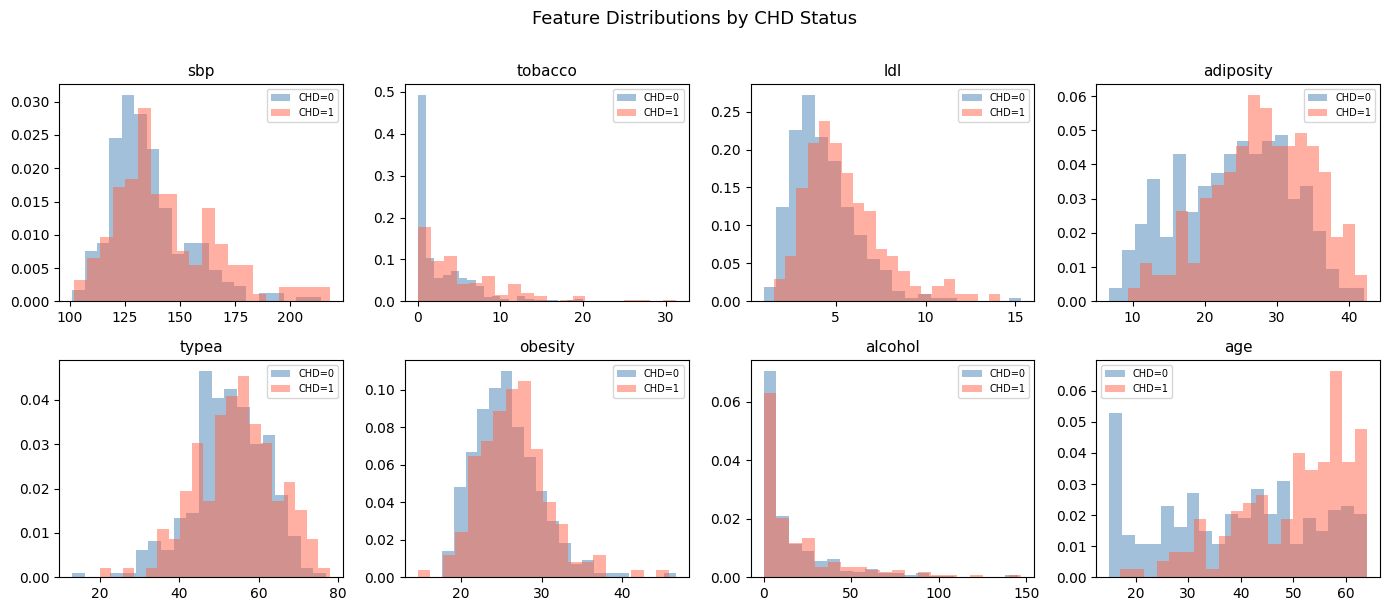

In [ ]:
# plot feature distributions by CHD result
continuous_cols = [
    "sbp",
    "tobacco",
    "ldl",
    "adiposity",
    "typea",
    "obesity",
    "alcohol",
    "age",
]

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, col in zip(axes.ravel(), continuous_cols):
    for label, colour in [(0, "steelblue"), (1, "tomato")]:
        ax.hist(
            df[df["chd"] == label][col],
            bins=20,
            alpha=0.5,
            label=f"CHD={label}",
            color=colour,
            density=True,
        )
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=7)
plt.suptitle("Feature Distributions by CHD Status", fontsize=13, y=1.01)
plt.tight_layout()
savefig("fig_histograms")
plt.show()

**Interpretation:**

Age, tobacco, and LDL show the clearest separation between CHD-positive and negative groups. Tobacco and alcohol are heavily right-skewed and most patients report low usage.

This skewness is worth noting but doesn't require transformation for the classifiers used (tree-based methods are invariant to monotonic transformations & logistic regression with standardised inputs should handles this adequately).


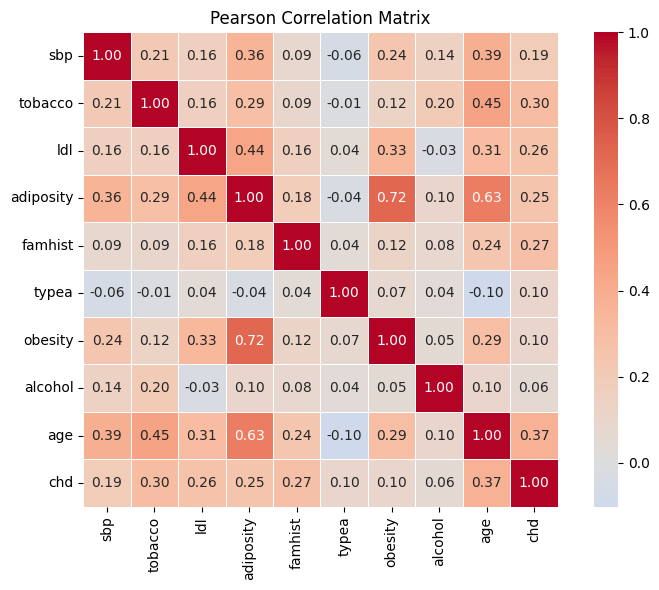

adiposity-obesity correlation: 0.717
adiposity-age correlation:     0.626


In [20]:
# Correlation heatmap
df_corr = df.copy()
df_corr["famhist"] = LabelEncoder().fit_transform(df_corr["famhist"])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    df_corr.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax,
    square=True,
    linewidths=0.5,
)
ax.set_title("Pearson Correlation Matrix")
plt.tight_layout()
savefig("fig_correlation")
plt.show()

print(
    f"adiposity-obesity correlation: {df_corr['adiposity'].corr(df_corr['obesity']):.3f}"
)
print(f"adiposity-age correlation:     {df_corr['adiposity'].corr(df_corr['age']):.3f}")

**Interpretation:** 

Adiposity and obesity (BMI) are strongly correlated (r=0.72) and, from prior domain knowledge, they measure overlapping aspects of body composition. 

Age correlates with adiposity (r=0.63) and tobacco (r=0.45), reflecting cumulative exposure over time. This multicollinearity motivates the use of ridge (L2) regularisation in logistic regression. Without it, coefficient estimates for correlated features become unstable

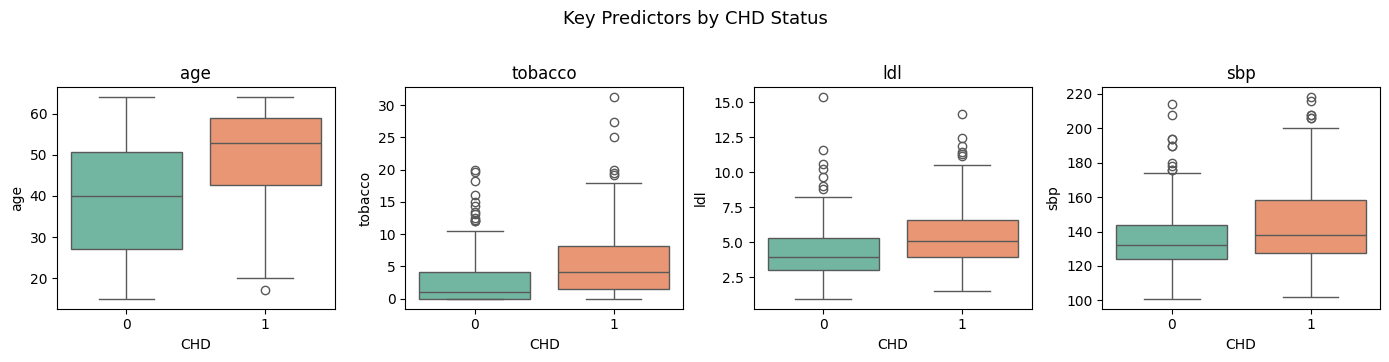

In [22]:
# Boxplots of key predictors
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, col in zip(axes, ["age", "tobacco", "ldl", "sbp"]):
    sns.boxplot(x="chd", y=col, data=df, ax=ax, palette="Set2")
    ax.set_xlabel("CHD")
    ax.set_title(col)
plt.suptitle("Key Predictors by CHD Status", fontsize=13, y=1.02)
plt.tight_layout()
savefig("fig_boxplots")
plt.show()

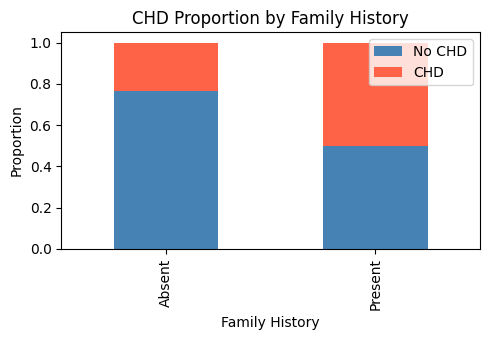

In [23]:
# Family history and CHD
ct = pd.crosstab(df["famhist"], df["chd"], normalize="index")
ct.plot(kind="bar", stacked=True, color=["steelblue", "tomato"], figsize=(5, 3.5))
plt.title("CHD Proportion by Family History")
plt.ylabel("Proportion")
plt.xlabel("Family History")
plt.legend(["No CHD", "CHD"], loc="upper right")
plt.tight_layout()
savefig("fig_famhist")
plt.show()

### 1b. Dimension reduction using PCA and factor analysis

Idea: exploring latent structure of the 9 features before classificationusing PCA and factor analysis. 

These were covered in week 08-09 and they help one to understand *why* certain classifiers succeed or fail.

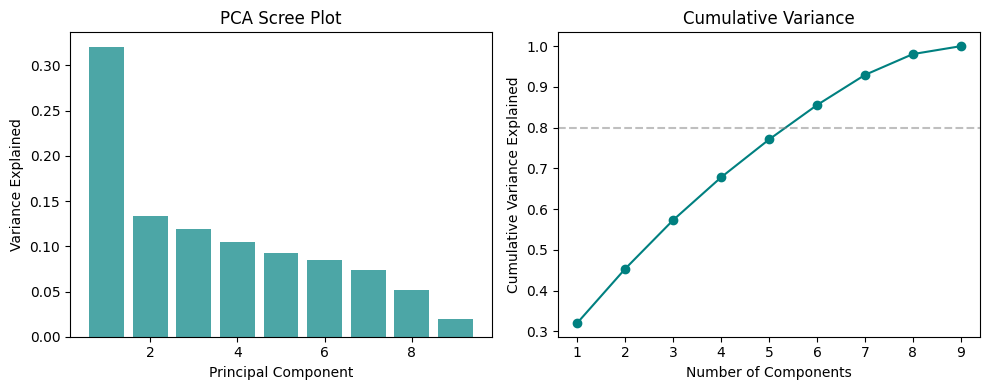

Variance explained by each PC:
  PC1: 0.321 (0.321 cumulative)
  PC2: 0.133 (0.454 cumulative)
  PC3: 0.120 (0.573 cumulative)
  PC4: 0.105 (0.678 cumulative)
  PC5: 0.093 (0.771 cumulative)
  PC6: 0.085 (0.855 cumulative)
  PC7: 0.074 (0.929 cumulative)
  PC8: 0.051 (0.981 cumulative)
  PC9: 0.019 (1.000 cumulative)


In [25]:
# PCA on standardised features (excluding target)
X_all = df_corr.drop("chd", axis=1)
X_std = StandardScaler().fit_transform(X_all)

pca = PCA().fit(X_std)

# Scree plot - how many components capture meaningful variance?
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.bar(range(1, 10), pca.explained_variance_ratio_, color="teal", alpha=0.7)
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Variance Explained")
ax1.set_title("PCA Scree Plot")

ax2.plot(range(1, 10), np.cumsum(pca.explained_variance_ratio_), "o-", color="teal")
ax2.axhline(0.8, ls="--", color="grey", alpha=0.5)
ax2.set_xlabel("Number of Components")
ax2.set_ylabel("Cumulative Variance Explained")
ax2.set_title("Cumulative Variance")

plt.tight_layout()
savefig("fig_pca_scree")
plt.show()

print("Variance explained by each PC:")
for i, v in enumerate(pca.explained_variance_ratio_):
    print(
        f"  PC{i+1}: {v:.3f} ({np.cumsum(pca.explained_variance_ratio_)[i]:.3f} cumulative)"
    )

**Interpretation:** 

The first 5 components explain ~77% of variance and 6 are needed to reach 80%. 

No single component dominates - PC1 captures only 32%, and the remaining variance is spread broadly. This diffuse structure suggests the data doesn't collapse neatly into a low-dimensional space, which foreshadows why non-linear models won't dramatically outperform linear ones.

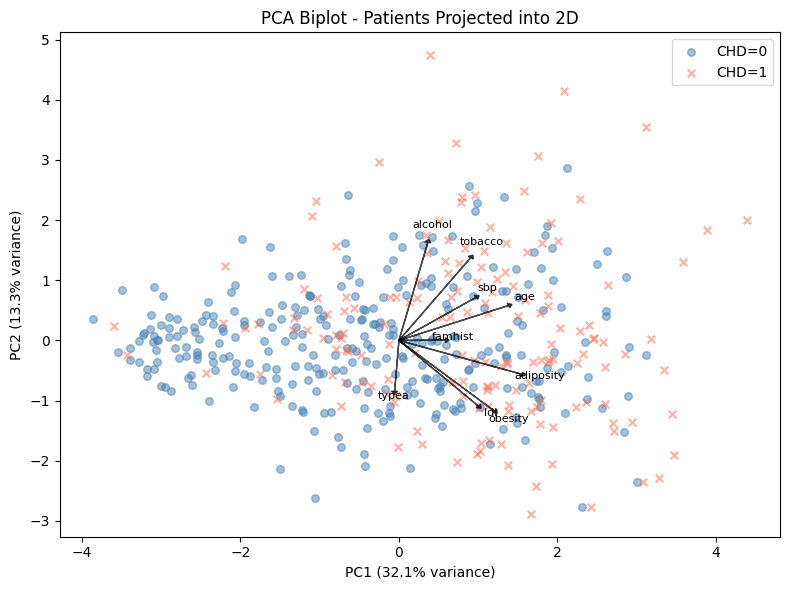

In [26]:
# PCA biplot - project patients into 2D, colour by CHD
pca2 = PCA(n_components=2).fit(X_std)
X_pca = pca2.transform(X_std)

fig, ax = plt.subplots(figsize=(8, 6))
for label, colour, marker in [(0, "steelblue", "o"), (1, "tomato", "x")]:
    mask = df_corr["chd"] == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colour, marker=marker,
              alpha=0.5, s=30, label=f"CHD={label}")

# Overlay feature loading arrows
loadings = pca2.components_.T
scale = 3  # scale arrows for visibility
for i, feat in enumerate(X_all.columns):
    ax.arrow(0, 0, loadings[i, 0]*scale, loadings[i, 1]*scale,
             head_width=0.08, head_length=0.05, fc="black", ec="black", alpha=0.7)
    ax.text(loadings[i, 0]*scale*1.15, loadings[i, 1]*scale*1.15,
            feat, fontsize=8, ha="center")

ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("PCA Biplot - Patients Projected into 2D")
ax.legend()
plt.tight_layout()
savefig("fig_pca_biplot")
plt.show()

**Interpretation:** 

The two classes overlap substantially in PCA space and there is no clean separation. 

tldr; the classification problem is genuinely difficult, and explains why we will see later that accuracy tops out around 74%. The loading arrows show that PC1 is driven by adiposity/obesity/age (body composition + aging), while PC2 captures tobacco/alcohol (lifestyle factors).

In [27]:
# Factor Analysis
# q: do interpretable latent factors emerge?
# Try 2 and 3 factors based on the scree plot
for n_factors in [2, 3]:
    fa = FactorAnalysis(n_components=n_factors, random_state=SEED)
    fa.fit(X_std)

    loadings_df = pd.DataFrame(
        fa.components_.T,
        index=X_all.columns,
        columns=[f"Factor {i+1}" for i in range(n_factors)],
    ).round(3)

    print(f"\n{'='*50}")
    print(f"Factor Analysis - {n_factors} factors")
    print(f"{'='*50}")
    print(loadings_df)
    print(f"\nTotal variance explained: {fa.score(X_std):.2f} (log-likelihood)")


Factor Analysis - 2 factors
           Factor 1  Factor 2
sbp           0.419    -0.129
tobacco       0.383    -0.310
ldl           0.455     0.075
adiposity     0.918     0.177
famhist       0.230    -0.105
typea        -0.048     0.141
obesity       0.686     0.492
alcohol       0.118    -0.066
age           0.774    -0.483

Total variance explained: -11.76 (log-likelihood)

Factor Analysis - 3 factors
           Factor 1  Factor 2  Factor 3
sbp          -0.427     0.090     0.104
tobacco      -0.406     0.275     0.173
ldl          -0.445    -0.122    -0.101
adiposity    -0.900    -0.262    -0.002
famhist      -0.238     0.086     0.043
typea         0.058    -0.127     0.077
obesity      -0.641    -0.533     0.017
alcohol      -0.131     0.072     0.723
age          -0.824     0.440    -0.050

Total variance explained: -11.73 (log-likelihood)


**Interpretation:** 

With 2 factors, a "metabolic/aging" factor emerges (loading on adiposity, obesity, age, sbp) and a "lifestyle" factor (loading on tobacco, alcohol). 

This is clinically interpretable and indicates that CHD risk comes from both cumulative body deterioration and behavioural choices. 

Factor 1 captures the correlated body-composition variables, explaining why ridge regression handles them effectively without needing to discard either.

Factor 1
High loaders: adiposity (0.92), age (0.77), obesity (0.69), ldl (0.46)
Interpretation: Metabolic accumulation — body composition + ageing

Factor 2
High loaders: obesity (0.49), age (-0.48), tobacco (-0.31)
Interpretation: Separates young-and-obese from old-and-smoking

Factor 1 is clean and clinically meaningful, representing a metabolic/ageing axis. 
Factor 2 is more difficult to interpret, which is not unusual in a restricted two-factor solution, and likely reflects residual contrast between different CHD risk profiles rather than a single latent trait.



In [29]:
# Descriptive stats split by CHD 
# to show which features differ between groups
df.groupby("chd").describe().T.round(2)

# more concise mean comparison
df.groupby("chd")[continuous_cols].mean().round(2).T
df.groupby("chd")[continuous_cols].mean().round(2).T.rename(
    columns={0: "No CHD", 1: "CHD"}
)

chd,No CHD,CHD
sbp,135.46,143.74
tobacco,2.63,5.52
ldl,4.34,5.49
adiposity,23.97,28.12
typea,52.37,54.49
obesity,25.74,26.62
alcohol,15.93,19.15
age,38.85,50.29


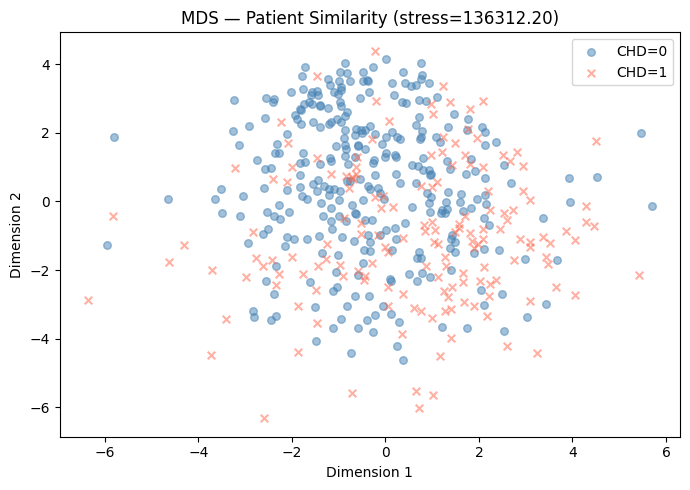

In [30]:
# MDS
# visualise patient similarity in 2D
# (preserve pairwise distances)
mds = MDS(n_components=2, random_state=SEED, normalized_stress="auto")
X_mds = mds.fit_transform(X_std)

fig, ax = plt.subplots(figsize=(7, 5))
for label, colour, marker in [(0, "steelblue", "o"), (1, "tomato", "x")]:
    mask = df_corr["chd"] == label
    ax.scatter(
        X_mds[mask, 0],
        X_mds[mask, 1],
        c=colour,
        marker=marker,
        alpha=0.5,
        s=30,
        label=f"CHD={label}",
    )
ax.set_title(f"MDS — Patient Similarity (stress={mds.stress_:.2f})")
ax.legend()
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
plt.tight_layout()
savefig("fig_mds")
plt.show()

**Interpretation:** 

Multidimensional scaling confirms what PCA showed -> the two classes are heavily interleaved. Healthy and CHD patients occupy overlapping regions of the feature space. 

This is why KNN (which relies on local distance) performs poorly, and why a global linear model (ridge LR) can perform competitively.

In [31]:
n_minority = df["chd"].sum()
n_majority = len(df) - n_minority
IR = n_majority / n_minority
p = df.shape[1] - 1  # 9 features, excluding target
print(f"Imbalance ratio: {IR:.2f}")
print(f"Features: {p}")
print(f"IR / sqrt(p): {IR / np.sqrt(p):.2f}")

Imbalance ratio: 1.89
Features: 9
IR / sqrt(p): 0.63


IR/√p = 0.63 — well below 1, confirming that the class imbalance is mild in the context of 9 features (Zhu et al., 2020). 

-> SMOTE is not warranted.

### Pairplot

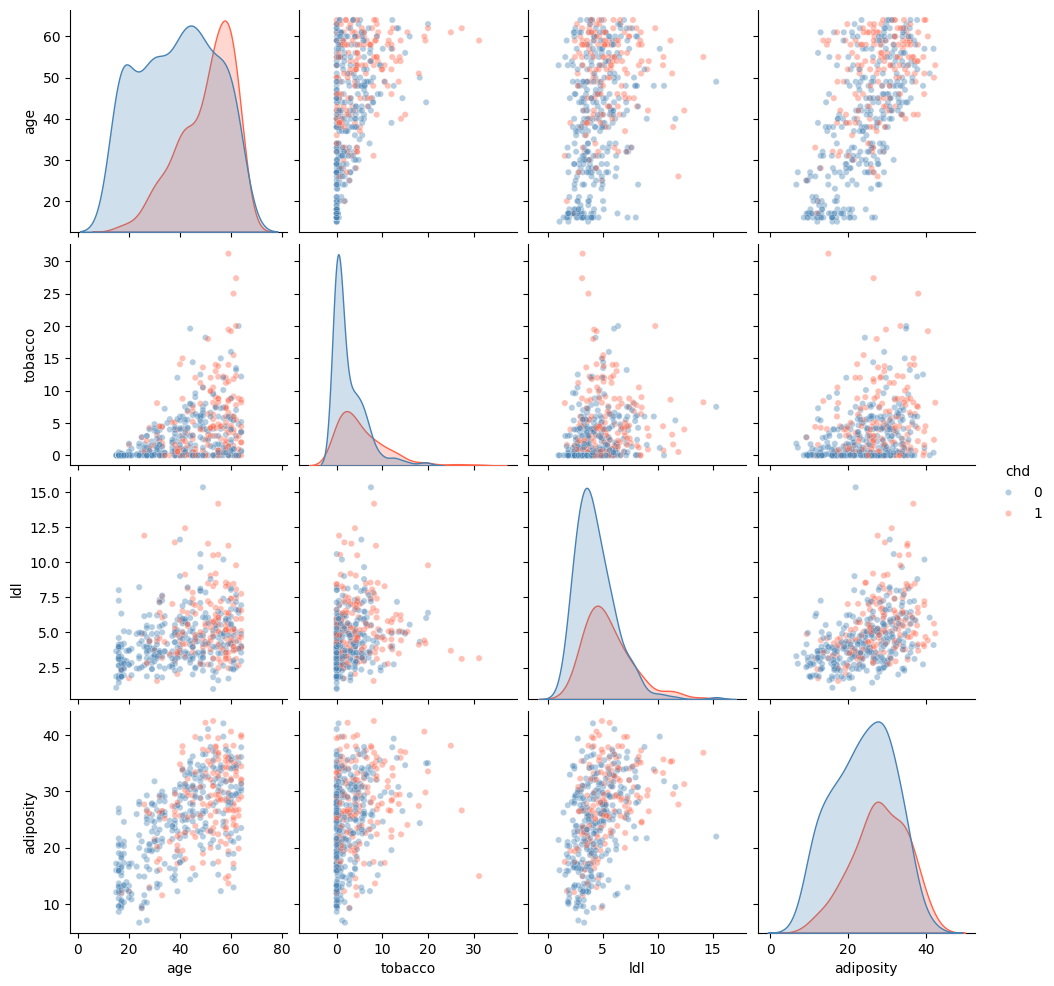

In [32]:
sns.pairplot(
    df,
    vars=["age", "tobacco", "ldl", "adiposity"],
    hue="chd",
    palette={0: "steelblue", 1: "tomato"},
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 20},
)

The age-adiposity scatter (bottom-left) shows the r=0.63 correlation visually, and every off-diagonal panel confirms the class overlap.

---

## 2. Data Preparation
